# Inverse potential problem 

For the inverse potential the goal is to find a homogeneous source given measurements at a circle enclosing the source. The Operator that maps the shape of a homogeneous heat source to the heat flux measured at some circle outside of the object is defined by the following partial differential equation. The heat distributions satisfies

$$
        \begin{cases}
            \Delta u = 1_K & \text{ in } \Omega \\
            u = 0          & \text{ on } \partial\Omega
        \end{cases}
$$

where $\partial\Omega$ is the measurement circle and $K$ is the heat source. The forward operator
maps the shape of the heat source to the Neumann data:

$$
        \partial K \mapsto \frac{\partial u}{\partial\nu}|_{\partial\Omega}.
$$

References:
- F. Hettlich & W. Rundell "Iterative methods for the reconstruction of an inverse potential problem", Inverse Problems, 12 (1996) 251–266.
- T. Hohage "Logarithmic convergence rates of the iteratively regularized Gauss–Newton method for an inverse potential and an inverse scattering problem", Inverse Problems, 13 (1997) 1279–1299.

## Import auxiliary libraries and define logging

We use `numpy` arrays as the main data structure for the domain and rely on `matplotlib.pyplot` as the tool for plots. 

To observe the information of the solver while computing we define the logging string and set the log level to info.

In [ ]:
import logging

import matplotlib.pyplot as plt
import numpy as np
from potential import Potential


logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-40s :: %(message)s'
)


example_dir = "../../../../examples/potential/"
Path(example_dir).resolve()
sys.path.insert(0, str(example_dir))

## Define Operator and regularization setting

The regularization setting is defined using a Sobolev penalty and $L^2$ data-fidelity. Note, that the construction here uses the abstract Sobolev which by default is the Sobolev space of with smoothness index 1. 

In [ ]:
from regpy.solvers import Setting
from regpy.hilbert import L2, Sobolev


#Forward operator
op = Potential(
    radius=1.3
)

setting = Setting(op=op, penalty=Sobolev, data_fid=L2)


2026-01-29 15:09:39,191 WARNING  Setting              :: Setting does not contain any explicit data.
2026-01-29 15:09:39,191 WARNING Setting                                  :: Setting does not contain any explicit data.


## The exact solution and data

For the exact solution we define an star shaped domain with boundary given by $ \sqrt{3\cos{t}^2+1}/2$. We then define the exact data and add noise with 3% relative noise level. 

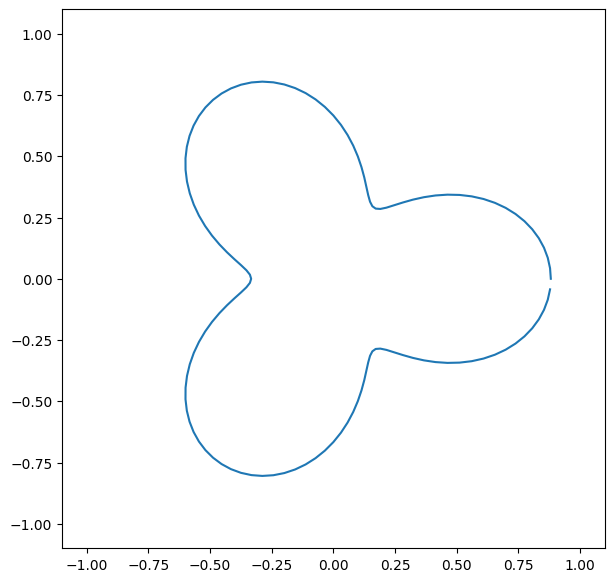

In [ ]:
#Exact data and Poission data
exact_solution = op.domain.radialfct2curve(lambda t: np.sqrt(6*np.cos(1.5*t)**2+1)/3)
exact_data = op(exact_solution.radial())
noise = op.codomain.randn()
noise = 0.03*setting.h_codomain.norm(exact_data)/setting.h_codomain.norm(noise) * noise
data = exact_data + noise

fig = plt.figure(figsize=(7,7))
plt.plot(*exact_solution.z)
ax = plt.gca()
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
plt.show()

## Solving the problem

With an initial guess that is the circle of radius 1 we use a Newton CG solver to get the solution. For a reference we plot the initial guess with the true objective. 

As stopping rules we rely on the discrepancy principle and to prevent an extensively long run we combine it with an iteration maximal count of 100.  

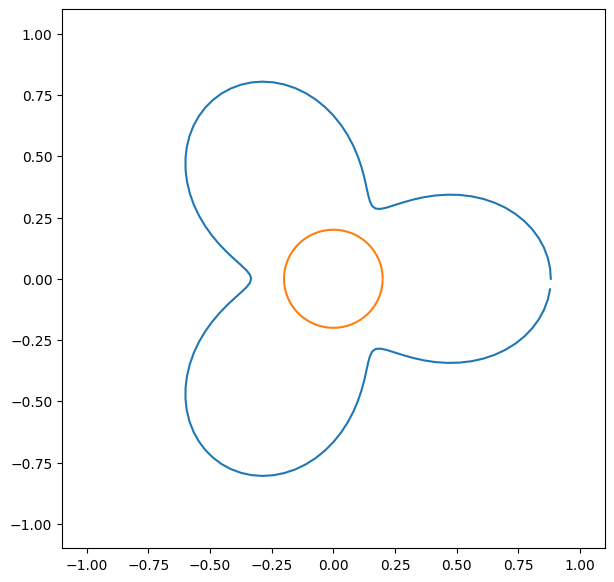

2026-01-29 15:09:39,825 WARNING  Discrepancy          :: Initialization of Discrepancy with two positional arguments (norm, data) deprecated. Use one positional argument (noiselevel) and specifiy norm and data via a keyword argument setting!
2026-01-29 15:09:39,825 WARNING Discrepancy                              :: Initialization of Discrepancy with two positional arguments (norm, data) deprecated. Use one positional argument (noiselevel) and specifiy norm and data via a keyword argument setting!


In [ ]:
#Initial guess
init = op.domain.circle(radius=0.2)

fig = plt.figure(figsize=(7,7))
plt.plot(*exact_solution.z)
plt.plot(*init.z)
ax = plt.gca()
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
plt.show()

from regpy.stoprules import CountIterations, Discrepancy

from regpy.solvers.nonlinear import NewtonCG
solver = NewtonCG(
    setting, 
    data, 
    init = init.coeff,
    cgmaxit=50, 
    rho=0.6
)

stoprule = (
    CountIterations(100) +
    Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel = setting.h_codomain.norm(noise),
        tau=1.1
    )
)

Run the iterative regularization method and plot results in each step

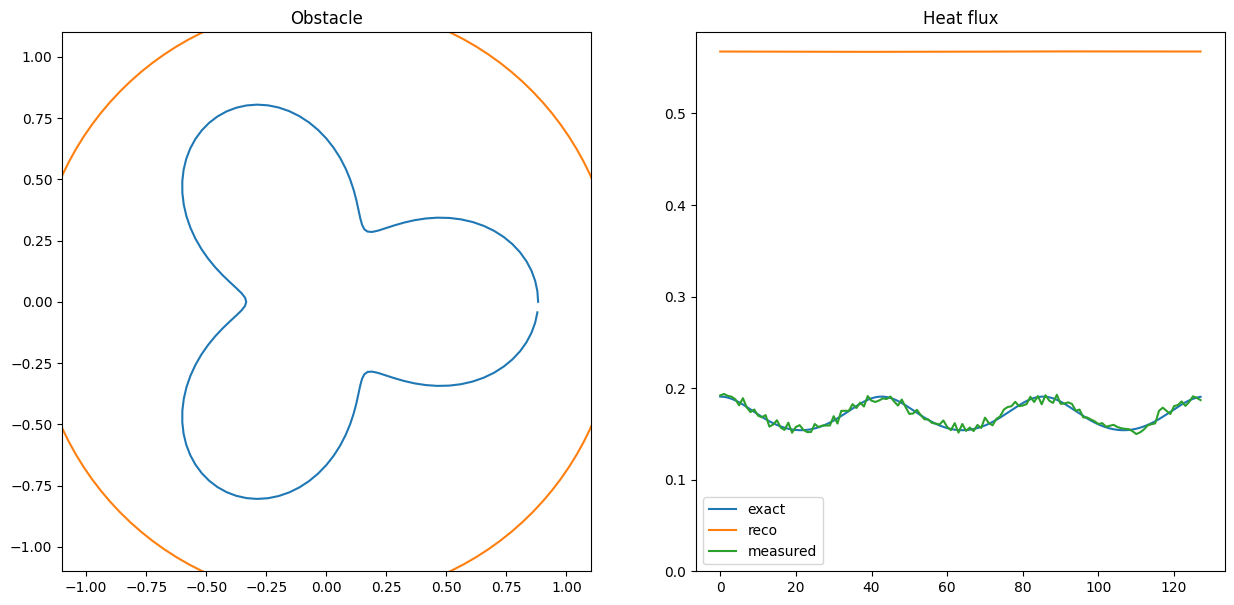

2026-01-29 15:09:40,045 INFO     CombineRules         :: it. 0>=100 | discr./noiselevel = 77.03< 1.10
2026-01-29 15:09:40,045 INFO CombineRules                             :: it. 0>=100 | discr./noiselevel = 77.03< 1.10


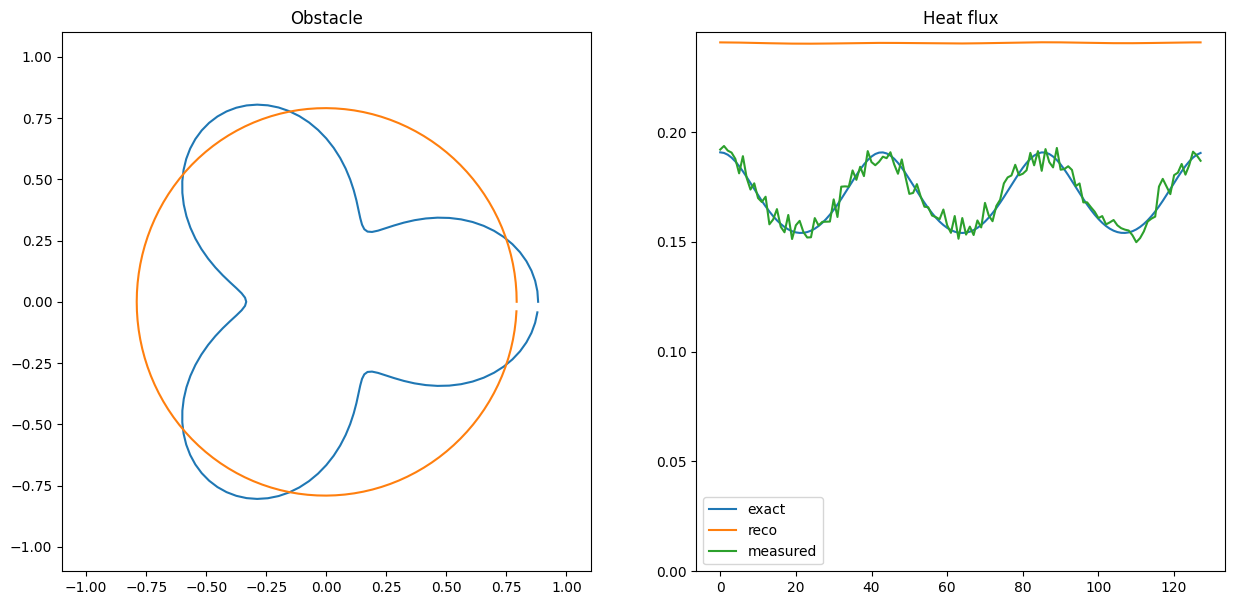

2026-01-29 15:09:40,292 INFO     CombineRules         :: it. 1>=100 | discr./noiselevel = 13.67< 1.10
2026-01-29 15:09:40,292 INFO CombineRules                             :: it. 1>=100 | discr./noiselevel = 13.67< 1.10


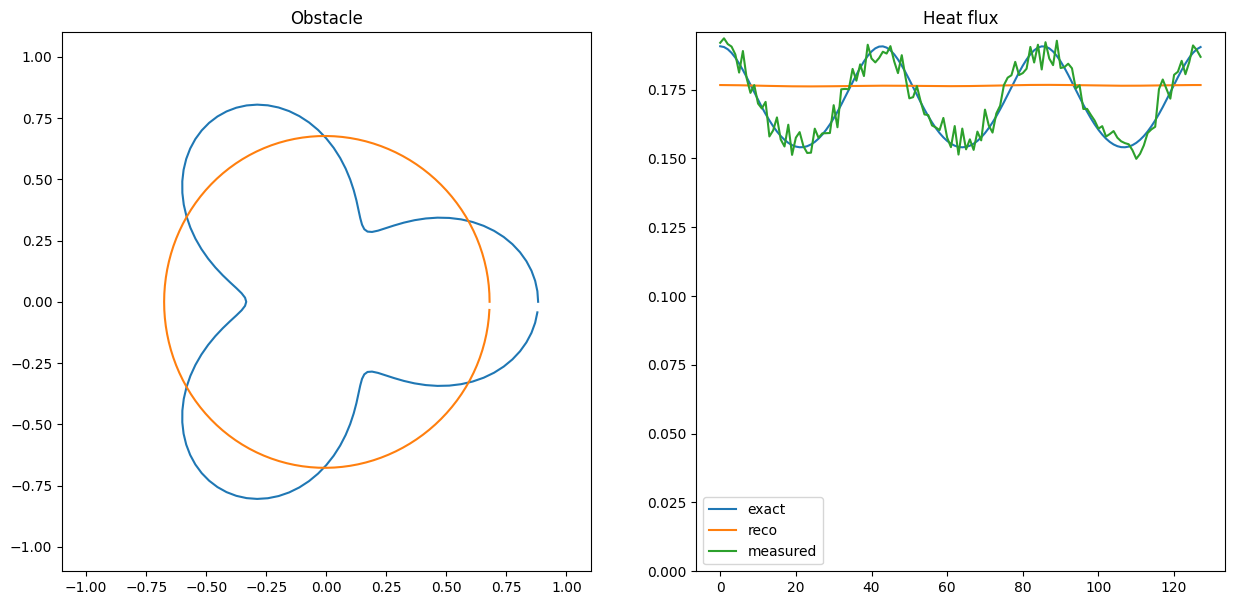

2026-01-29 15:09:40,490 INFO     CombineRules         :: it. 2>=100 | discr./noiselevel = 2.74< 1.10
2026-01-29 15:09:40,490 INFO CombineRules                             :: it. 2>=100 | discr./noiselevel = 2.74< 1.10


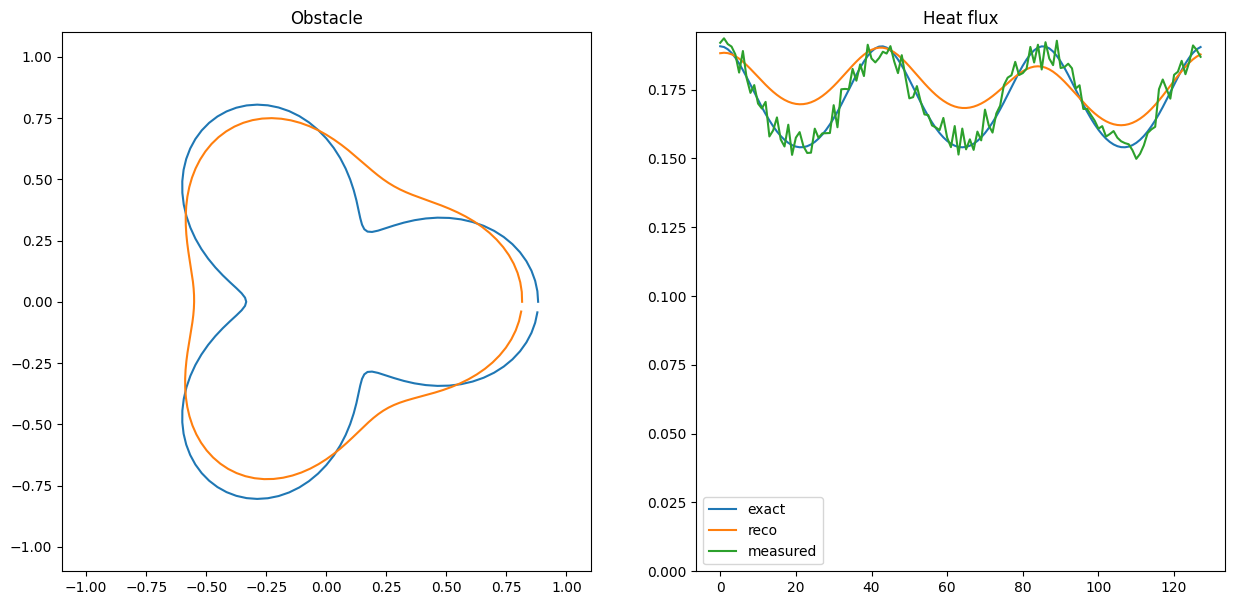

2026-01-29 15:09:40,684 INFO     CombineRules         :: it. 3>=100 | discr./noiselevel = 1.81< 1.10
2026-01-29 15:09:40,684 INFO CombineRules                             :: it. 3>=100 | discr./noiselevel = 1.81< 1.10


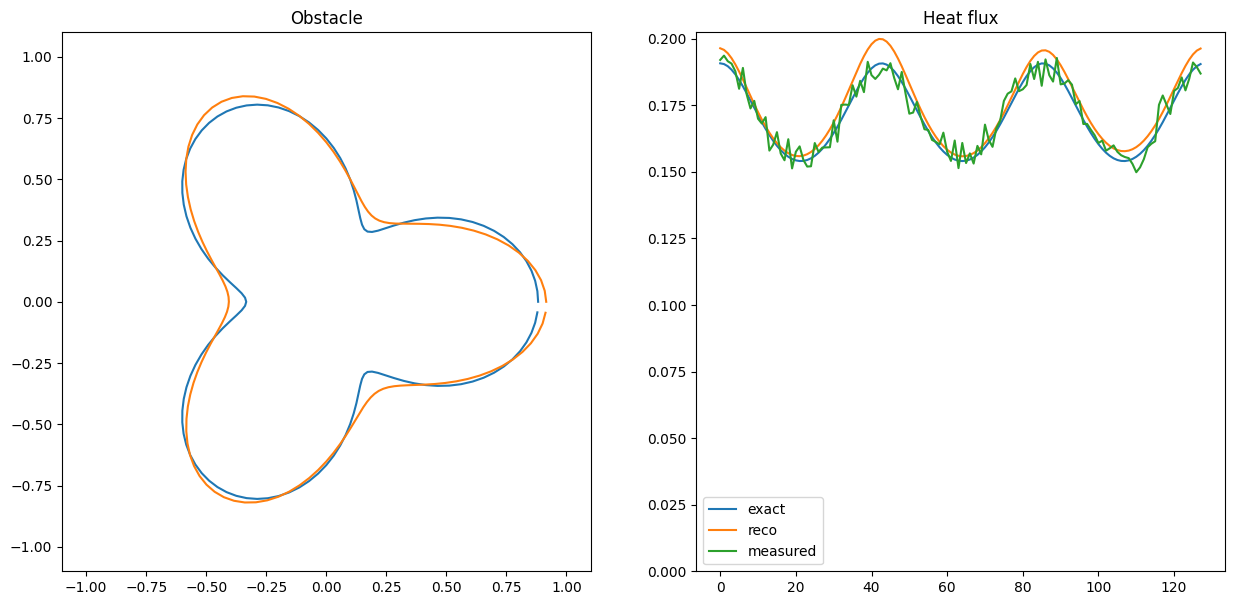

2026-01-29 15:09:40,958 INFO     CombineRules         :: it. 4>=100 | discr./noiselevel = 1.28< 1.10
2026-01-29 15:09:40,958 INFO CombineRules                             :: it. 4>=100 | discr./noiselevel = 1.28< 1.10


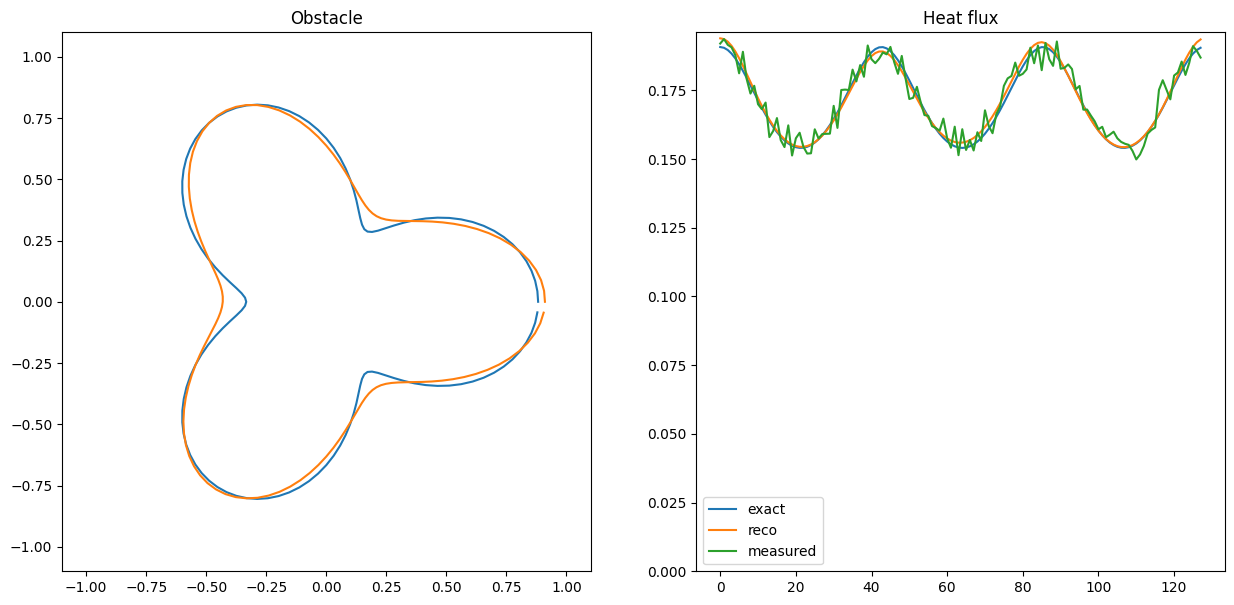

2026-01-29 15:09:41,230 INFO     CombineRules         :: it. 5>=100 | discr./noiselevel = 1.00< 1.10
Rule Discrepancy(noiselevel=0.012891189621064078, tau=1.1) triggered.
2026-01-29 15:09:41,230 INFO CombineRules                             :: it. 5>=100 | discr./noiselevel = 1.00< 1.10
Rule Discrepancy(noiselevel=0.012891189621064078, tau=1.1) triggered.


In [ ]:
for reco,reco_data in solver.until(stoprule=stoprule):
    fig, axs = plt.subplots(1, 2,figsize=(15,7))
    axs[0].set_title('Obstacle')
    axs[0].set_xlim([-1.1, 1.1])
    axs[0].set_ylim([-1.1, 1.1])
    axs[1].set_title('Heat flux')

    axs[0].plot(*exact_solution.z)
    axs[0].plot(*op.curve.z)

    axs[1].plot(exact_data.real, label='exact')
    axs[1].plot(reco_data.real, label='reco')
    axs[1].plot(data.real, label='measured')
    axs[1].legend()
    axs[1].set_ylim(ymin=0)

    plt.show()